In [2]:
import os
import getpass
import numpy as np

In [3]:
from huggingface_hub import login
hf_token = getpass.getpass("Enter your Hugging Face token: ")
login(token=hf_token)

Enter your Hugging Face token:  ········


In [4]:
from transformers import pipeline
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

# Check if model is already loaded to avoid OOM errors
if 'pipe' not in globals():
    # Load the 4B instruction-tuned model
    pipe = pipeline(
        "image-text-to-text",
        model="edziocodes/medgemma-breast-cancer",
        torch_dtype=torch.bfloat16,
        device="cuda" if torch.cuda.is_available() else "cpu",
        token=os.environ.get("HF_TOKEN"),  # Pass token for gated model
    )
    print(f"✓ Model loaded on: {pipe.device}")
else:
    print(f"✓ Model already loaded on: {pipe.device}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/884 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

DecodingError: brotli: decoder process called with data when 'can_accept_more_data()' is False

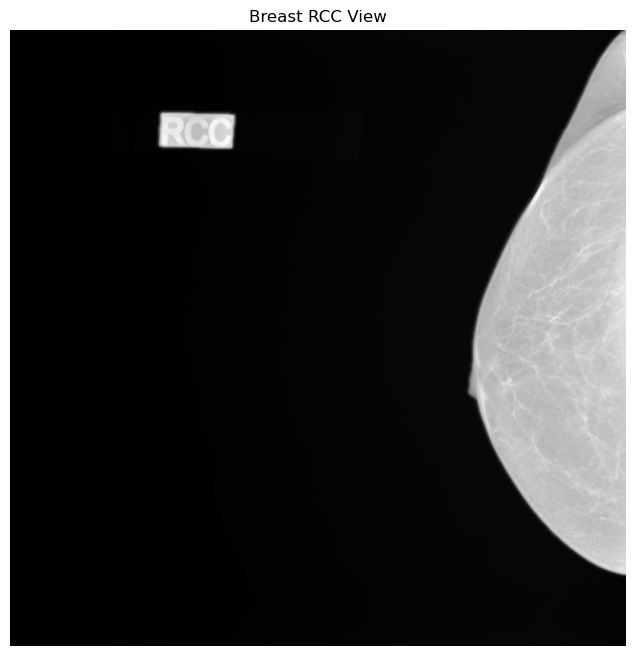

In [4]:
# Load chest X-ray image
image = np.load('/raid/mpsych/OMAMA/DATA/data/2d_resized_1024/images/100000039159562031368112550794429920461.npz')['data']

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Breast RCC View')
plt.show()

In [10]:
# Ask about specific conditions
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Classify this mammogram.\nA: NonCancer\nB: Cancer"}
        ]
    }
]

output = pipe(text=messages, max_new_tokens=500)
print("Disease Analysis:")
print(output[0]["generated_text"][-1]["content"])


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Disease Analysis:
Based on the image, the classification is **A: NonCancer**.

